In [2]:
import os
import sys
import time
import numpy as np
import torch
import torch.optim as optim
from tqdm import tqdm
from pathlib import Path

from imu_ssl.datasets.data_index import DataIndex
from imu_ssl.datasets.imu_dataset import build_dataloader, IMUDataset
from imu_ssl.datasets.imu_augmentation import Compose, Jitter, Scaling, RandomCrop, TimeWarp
from imu_ssl.models.tcn_encoder import TCNEncoder
from imu_ssl.models.SimCLR_model import SimCLR
from imu_ssl.inference.simclr_inference import SimCLRInference


In [3]:
# Use absolute path since __file__ is not available in notebooks
PROJECT_ROOT = Path(os.getcwd()).parent if "scripts" in os.getcwd() else Path(os.getcwd()) / "imu_ssl"
DATA_DIR = PROJECT_ROOT / "data"

CHECKPOINT = PROJECT_ROOT / "checkpoints" / "best.pt"
TRAIN_METADATA = DATA_DIR / "metadata_train.json"
VAL_METADATA = DATA_DIR / "metadata_val.json"

BATCH_SIZE = 32
SEQ_LEN = 1440
EPOCHS = 20
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"TRAIN_METADATA: {TRAIN_METADATA}")
print(f"Using device: {DEVICE}")

PROJECT_ROOT: d:\Desktop\MCI-project\imu_ssl
DATA_DIR: d:\Desktop\MCI-project\imu_ssl\data
TRAIN_METADATA: d:\Desktop\MCI-project\imu_ssl\data\metadata_train.json
Using device: cuda


In [ ]:
def get_augmentation():
    return Compose([
        Jitter(0.01),
        Scaling(0.1),
        RandomCrop(0.9),
        TimeWarp(0.2),
    ])


In [5]:
def train_simclr():
    loss_history = []
    print("Loading metadata:", TRAIN_METADATA)
    index = DataIndex(TRAIN_METADATA)
    train_files = index.all_file_list()
    print("Train samples:", len(train_files))

    augment = get_augmentation()
    train_loader = build_dataloader(
        train_files,
        batch_size=BATCH_SIZE,
        shuffle=True,
        target_seq_len=SEQ_LEN,
        augment=augment,
    )

    encoder = TCNEncoder(input_ch=9)
    model = SimCLR(encoder).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_loss = float("inf")

    for epoch in range(1, EPOCHS + 1):
        print(f"Epoch {epoch}/{EPOCHS}")
        model.train()
        epoch_loss_sum = 0.0

        for x1, x2 in tqdm(train_loader):
            x1 = x1.to(DEVICE)
            x2 = x2.to(DEVICE)

            loss = model(x1, x2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss_sum += loss.item()

        avg_loss = epoch_loss_sum / len(train_loader)
        loss_history.append(avg_loss)
        scheduler.step()
        print("avg_loss=", avg_loss)

        torch.save(model.state_dict(), PROJECT_ROOT / "checkpoints" / "latest.pt")
        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model.state_dict(), PROJECT_ROOT / "checkpoints" / "best.pt")
            print("✓ updated best model:", best_loss)

    print("Training finished.")
    return loss_history



Loading metadata: d:\Desktop\MCI-project\imu_ssl\data\metadata_train.json
Train samples: 318
Epoch 1/20
Epoch 1/20


100%|██████████| 10/10 [00:01<00:00,  6.83it/s]


avg_loss= 1.1180442690849304
✓ updated best model: 1.1180442690849304
Epoch 2/20


100%|██████████| 10/10 [00:01<00:00,  9.16it/s]



avg_loss= 0.5758289128541947
✓ updated best model: 0.5758289128541947
Epoch 3/20


...

avg_loss= 0.12572398409247398
✓ updated best model: 0.12572398409247398
Epoch 19/20


100%|██████████| 10/10 [00:01<00:00,  9.24it/s]



avg_loss= 0.12387177050113678
✓ updated best model: 0.12387177050113678
Epoch 20/20


100%|██████████| 10/10 [00:01<00:00,  9.43it/s]



avg_loss= 0.1267728663980961
Training finished.


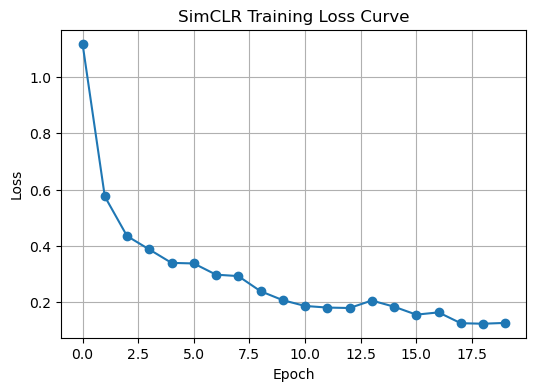

In [6]:
loss_history = train_simclr()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(loss_history, marker='o')
plt.title("SimCLR Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


In [7]:
def extract_embeddings(model, file_list):
    embeddings, labels = [], []
    for path in tqdm(file_list):
        imu, _ = IMUDataset._load_hdf5(IMUDataset, path)
        emb = model.encode(imu)
        embeddings.append(emb)
        labels.append(os.path.basename(os.path.dirname(path)))
    return np.vstack(embeddings), np.array(labels)

def recall_at_k(embeddings, labels, k=5):
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    N = len(embeds)
    recalls = []

    for i in range(N):
        query_label = labels[i]

        same_class_idx = np.where(labels == query_label)[0]
        total_relevant = len(same_class_idx) - 1

        if total_relevant <= 0:
            continue

        sims = embeds @ embeds[i]
        sims[i] = -1
        topk_idx = np.argsort(-sims)[:k]

        retrieved_relevant = np.sum(labels[topk_idx] == query_label)

        recall = retrieved_relevant / total_relevant
        recalls.append(recall)

    return np.mean(recalls)


def compute_map(embeddings, labels):
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    N = len(embeds)
    APs = []

    for i in range(N):
        query_label = labels[i]

        # Compute similarity
        sims = embeds @ embeds[i]
        sims[i] = -1
        ranked = np.argsort(-sims)
        ranked_labels = labels[ranked]

        # Find relevant indices
        relevant_mask = ranked_labels == query_label
        rel_pos = np.where(relevant_mask)[0]  # ranked positions of relevant items

        # If no relevant items exist other than itself → skip
        if len(rel_pos) == 0:
            APs.append(0.0)
            continue

        # Compute precision at each relevant retrieval
        precisions = []
        for idx, pos in enumerate(rel_pos):
            precision_at_pos = (idx + 1) / (pos + 1)
            precisions.append(precision_at_pos)

        APs.append(np.mean(precisions))

    return np.mean(APs)



In [12]:
index = DataIndex(VAL_METADATA)
val_files = index.all_file_list()

model = SimCLRInference(CHECKPOINT, device=DEVICE)

embeddings, labels = extract_embeddings(model, val_files)

r1 = recall_at_k(embeddings, labels, k=1)
r5 = recall_at_k(embeddings, labels, k=5)
mAP = compute_map(embeddings, labels)

print("Recall@1 =", r1)
print("Recall@5 =", r5)
print("mAP =", mAP)


100%|██████████| 28/28 [00:00<00:00, 165.96it/s]

Recall@1 = 0.10714285714285716
Recall@5 = 0.2653061224489796
mAP = 0.3928488501381592


In [15]:
def retrieval_report(file_list, embeddings, labels, query_idx, top_k=None):
    """
    打印检索报告：
      - Query index / label / path
      - 当前类总样本数
      - 检索排序结果（rank → label / similarity / file name）
    
    Args:
        file_list: list of file paths, len=N
        embeddings: (N, D) array
        labels: (N,) array (string labels)
        query_idx: int, index of the query
        top_k: 若为 None → 显示所有 rank；否则显示前 top_k
    """

    import numpy as np
    import os

    N = len(embeddings)
    assert 0 <= query_idx < N

    # --------------------------
    # Query 信息
    # --------------------------
    query_path = file_list[query_idx]
    query_label = labels[query_idx]

    # 当前类的样本数量
    class_mask = (labels == query_label)
    class_total = np.sum(class_mask)

    print("\n========================================================")
    print(f"QUERY #{query_idx}")
    print(f"Label:           {query_label}")
    print(f"File:            {query_path}")
    print(f"Class size:      {class_total} samples")
    print("========================================================\n")

    # --------------------------
    # 相似度计算
    # --------------------------
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    q = embeddings[query_idx] / np.linalg.norm(embeddings[query_idx])

    sims = embeds @ q
    sims[query_idx] = -1  # 不与自己比

    ranked_idx = np.argsort(-sims)
    if top_k is not None:
        ranked_idx = ranked_idx[:top_k]

    # --------------------------
    # 输出表格
    # --------------------------
    print(f"{'Rank':<6}{'Label':<22}{'Sim':<10}File")
    print("-" * 70)

    for rank, idx in enumerate(ranked_idx, start=1):
        label = labels[idx]
        sim = sims[idx]
        fname = os.path.basename(file_list[idx])
        print(f"{rank:<6}{label:<22}{sim:<10.4f}{fname}")

    print("\n========================================================\n")


In [20]:
top_idx = retrieval_report(val_files, embeddings, labels, query_idx=13, top_k=20)


QUERY #13
Label:           open_close_notebook
File:            D:\Desktop\MCI-project\imu_ssl\data\validate_set\open_close_notebook\open_close_notebook_20251202_151128.hdf5
Class size:      8 samples

Rank  Label                 Sim       File
----------------------------------------------------------------------
1     open_close_notebook   0.8735    open_close_notebook_20251202_151147.hdf5
2     use_hammer            0.8506    use_hammer_20251202_223953.hdf5
3     use_hammer            0.8312    use_hammer_20251202_224259.hdf5
4     open_close_notebook   0.7974    open_close_notebook_20251202_151209.hdf5
5     pick_and_place        0.7452    pick_and_place_20251202_160842.hdf5
6     open_close_notebook   0.7423    open_close_notebook_20251202_151013.hdf5
7     clap_once             0.6890    clap_once_20251116_165201.hdf5
8     use_hammer            0.6884    use_hammer_20251202_225357.hdf5
9     pick_and_place        0.5982    pick_and_place_20251108_213442.hdf5
10    pick_and_plac

# Visualization

In [9]:
def plot_imu(curve, title, figsize=(10,3)):
    """
    curve: (T, 9)
    """
    plt.figure(figsize=figsize)
    for i in range(curve.shape[1]):
        plt.plot(curve[:, i], label=f"ch{i}")
    plt.title(title)
    plt.legend(ncol=3, fontsize=8)
    plt.tight_layout()
    plt.show()


In [10]:
def retrieval_demo(model, file_list, embeddings, labels, k=5, idx=None):
    import numpy as np
    from imu_ssl.datasets.imu_dataset import IMUDataset

    if idx is None:
        idx = np.random.randint(0, len(file_list))

    query_path = file_list[idx]
    query_label = labels[idx]
    query_embed = embeddings[idx]

    # load IMU
    imu, _ = IMUDataset._load_hdf5(IMUDataset, query_path)

    # ---- Plot Query ----
    plot_imu(
        imu,
        title=f"[QUERY] label={query_label}   path={os.path.basename(query_path)}"
    )

    # ---- Compute similarity ----
    embeds = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    q = query_embed / np.linalg.norm(query_embed)

    sims = embeds @ q
    sims[idx] = -1

    topk_idx = np.argsort(-sims)[:k]

    print("\nTop-k retrieved results:\n")
    for rank, i in enumerate(topk_idx):
        print(f"#{rank+1}  label={labels[i]}  path={file_list[i]}  sim={sims[i]:.4f}")

        # Load IMU and plot
        imu_i, _ = IMUDataset._load_hdf5(IMUDataset, file_list[i])
        plot_imu(
            imu_i,
            title=f"[Rank {rank+1}] label={labels[i]}  sim={sims[i]:.4f}"
        )


100%|██████████| 28/28 [00:00<00:00, 442.90it/s]



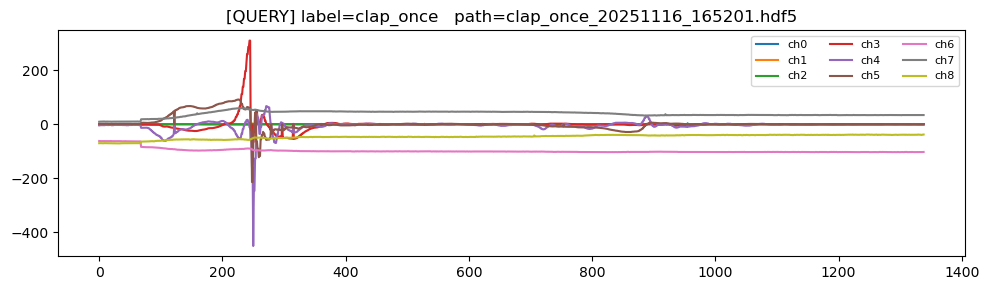


Top-k retrieved results:

#1  label=use_hammer  path=D:\Desktop\MCI-project\imu_ssl\data\validate_set\use_hammer\use_hammer_20251202_223953.hdf5  sim=0.8509


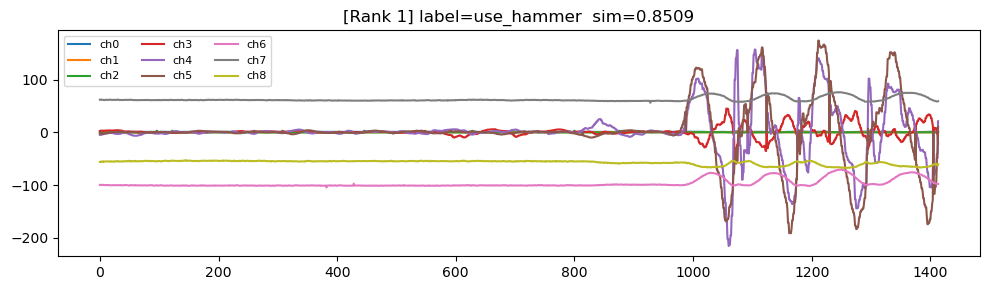

#2  label=use_hammer  path=D:\Desktop\MCI-project\imu_ssl\data\validate_set\use_hammer\use_hammer_20251202_225357.hdf5  sim=0.8139


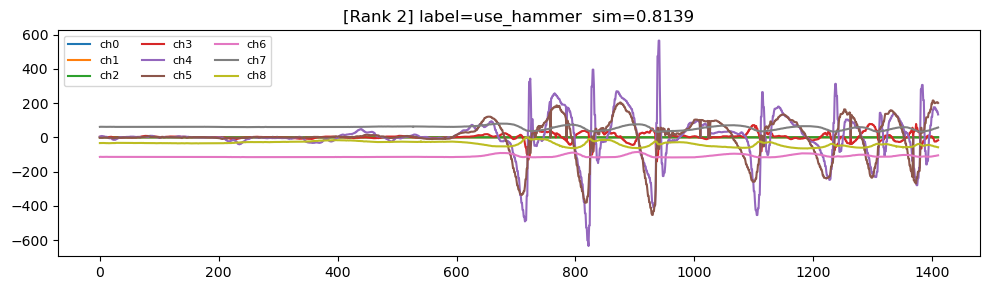

#3  label=use_hammer  path=D:\Desktop\MCI-project\imu_ssl\data\validate_set\use_hammer\use_hammer_20251202_224259.hdf5  sim=0.7900


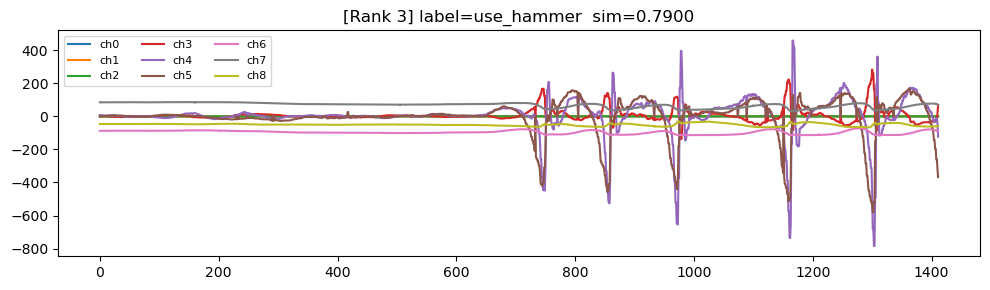

#4  label=open_close_notebook  path=D:\Desktop\MCI-project\imu_ssl\data\validate_set\open_close_notebook\open_close_notebook_20251202_151128.hdf5  sim=0.6890


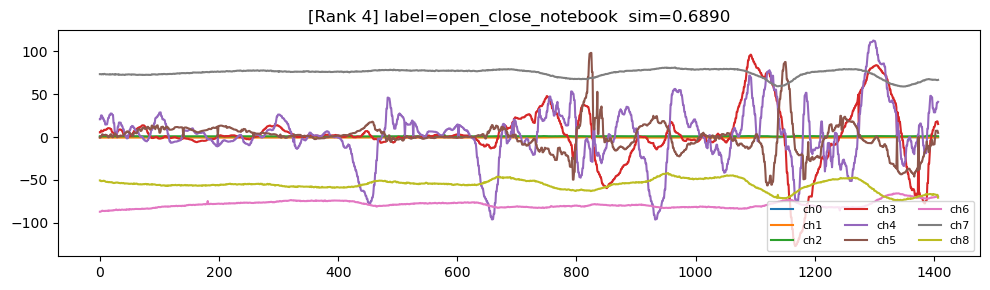

#5  label=pick_and_place  path=D:\Desktop\MCI-project\imu_ssl\data\validate_set\pick_and_place\pick_and_place_20251202_160842.hdf5  sim=0.6474


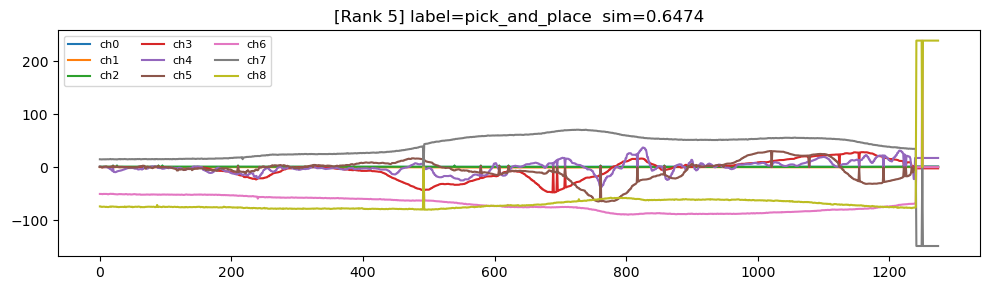

In [11]:
# Load validation metadata
index = DataIndex(VAL_METADATA)
val_files = index.all_file_list()

# Load model
simclr = SimCLRInference(CHECKPOINT, device=DEVICE)

# Extract embeddings
embeddings, labels = extract_embeddings(simclr, val_files)

# Demo
retrieval_demo(simclr, val_files, embeddings, labels, k=5)
